# 学生成绩层次聚类实验
## 无监督学习：层次聚类（Hierarchical Clustering）

### 1. 基础知识简介

层次聚类是一类无监督学习方法，通过逐步合并（或拆分）样本来形成层次结构。
常见做法是**凝聚式层次聚类**：从每个样本作为一个簇开始，不断合并最相近的簇，直到达到设定的簇数或距离阈值。

**适用场景**：样本数中等、需要理解簇之间层次关系的任务。
**优点**：不必事先指定簇形状，可输出树状图，便于解释。
**不足**：计算开销较大，对噪声较敏感。

### 2. 数据集说明

本实验使用学生成绩公开数据集（student-mat.csv），包含学生的家庭、学习习惯与成绩等信息。
数据文件位于本目录：`student-mat.csv`（分号分隔）。
本实验仅使用其中的**数值特征**进行聚类分析。

### 3. 实验环境与依赖

- Python 3.10+
- pandas, numpy
- matplotlib, seaborn
- scikit-learn
- scipy

### 4. 导入必要的库

In [40]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib import font_manager

# 设置中文字体（强制使用可用中文字体，避免回退到 Arial）
font_paths = [
    r"C:\\Windows\\Fonts\\msyh.ttc",      # Microsoft YaHei
    r"C:\\Windows\\Fonts\\simhei.ttf",   # SimHei
    r"C:\\Windows\\Fonts\\simsun.ttc"    # SimSun
]
for fp in font_paths:
    if os.path.exists(fp):
        font_manager.fontManager.addfont(fp)

preferred_fonts = [
    'Microsoft YaHei',
    'SimHei',
    'SimSun',
    'Noto Sans CJK SC',
    'WenQuanYi Zen Hei'
]
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CHINESE_FONT = None
for f in preferred_fonts:
    if f in available_fonts:
        CHINESE_FONT = f
        break

if CHINESE_FONT:
    mpl.rcParams['font.family'] = CHINESE_FONT
    mpl.rcParams['font.sans-serif'] = [CHINESE_FONT]
    sns.set_theme(style='whitegrid', font=CHINESE_FONT)
else:
    sns.set_theme(style='whitegrid')

mpl.rcParams['axes.unicode_minus'] = False

### 5. 读取数据与基本查看

说明：该数据集使用分号作为分隔符。

In [41]:
df = pd.read_csv('student/student-mat.csv', sep=';')
print('数据集形状:', df.shape)
display(df.head())
display(df.describe(include='all'))

数据集形状: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395,395,395.000000,395,395,395,395.000000,395.000000,395,395,...,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
unique,2,2,NaN,2,2,2,NaN,NaN,5,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,GP,F,NaN,U,GT3,T,NaN,NaN,other,other,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,349,208,NaN,307,281,354,NaN,NaN,141,217,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,16.696203,NaN,NaN,NaN,2.749367,2.521519,NaN,NaN,...,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,NaN,NaN,1.276043,NaN,NaN,NaN,1.094735,1.088201,NaN,NaN,...,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,NaN,NaN,15.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,NaN,NaN,16.000000,NaN,NaN,NaN,2.000000,2.000000,NaN,NaN,...,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,NaN,NaN,17.000000,NaN,NaN,NaN,3.000000,2.000000,NaN,NaN,...,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,NaN,NaN,18.000000,NaN,NaN,NaN,4.000000,3.000000,NaN,NaN,...,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000


### 6. 缺失值检查

说明：若存在缺失值，可选择删除或用统计量填充。本实验先检查是否有缺失。

In [42]:
missing = df.isna().sum()
display(missing[missing > 0])

Series([], dtype: int64)

### 7. 选择数值特征并做基础探索

说明：层次聚类基于距离计算，先选择数值型特征。

数值特征数量: 16


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,18,4,4,2,2,0,4,3,4,1,1,3,6,5,6,6
1,17,1,1,1,2,0,5,3,3,1,1,3,4,5,5,6
2,15,1,1,1,2,3,4,3,2,2,3,3,10,7,8,10
3,15,4,2,1,3,0,3,2,2,1,1,5,2,15,14,15
4,16,3,3,1,2,0,4,3,2,1,2,5,4,6,10,10


<Figure size 1000x600 with 0 Axes>

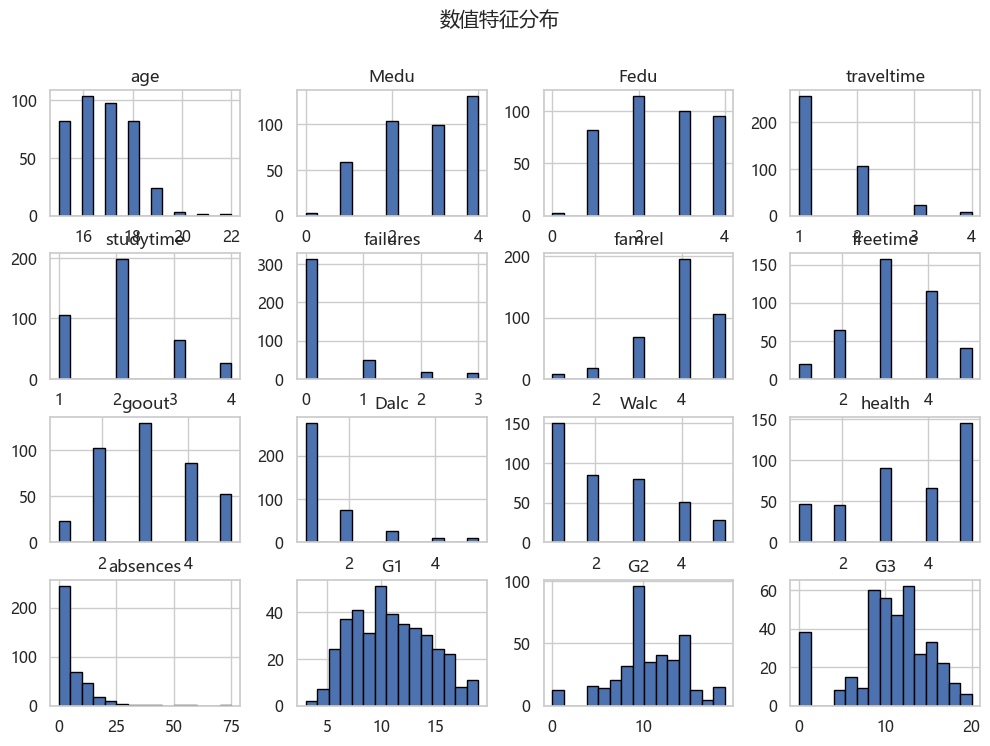

In [43]:
num_df = df.select_dtypes(include=[np.number])
print('数值特征数量:', num_df.shape[1])
display(num_df.head())

plt.figure(figsize=(10, 6))
num_df.hist(bins=15, figsize=(12, 8), edgecolor='black')
plt.suptitle('数值特征分布')
plt.show()

#### 图表解读与知识点

**图表解读（数值特征分布图）：**
- 每个子图对应一个数值特征的分布。
- 看**偏态**：明显右偏/左偏说明该特征有极端值或集中区间。
- 看**离散度**：分布越宽，特征差异越大，可能更影响聚类。
- 看**多峰**：若出现多个峰，可能存在潜在分组。

**知识点讲解：**
- 层次聚类依赖**距离**，分布差异大的特征会主导距离计算。
- 对偏态严重或量纲差异大的特征，应考虑**标准化**（本实验第8部分）。
- 可进一步只保留与成绩相关的特征进行对比实验。

### 8. 标准化特征

说明：不同特征量纲差异会影响距离计算，因此需要标准化。

In [44]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(num_df)
print('标准化后均值(约为0):', X_scaled.mean(axis=0)[:5])
print('标准化后标准差(约为1):', X_scaled.std(axis=0)[:5])

标准化后均值(约为0): [ 1.22321281e-15  5.39652711e-17 -1.43907390e-16  6.29594829e-17
 -2.11363978e-16]
标准化后标准差(约为1): [1. 1. 1. 1. 1.]


### 9. 树状图（Dendrogram）

说明：树状图用于观察样本逐步合并的过程，可辅助判断合理的簇数。
这里使用 Ward 链接方式作为主流程。

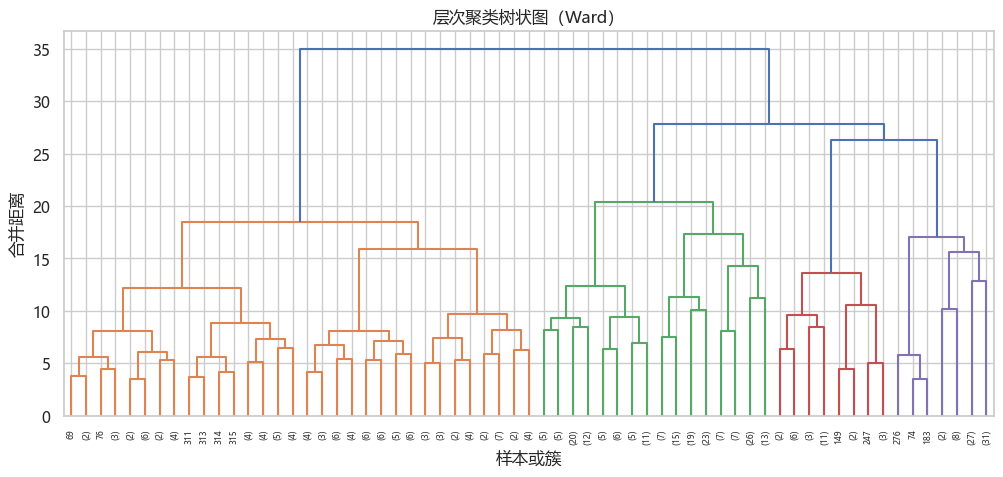

In [45]:
Z = linkage(X_scaled, method='ward')
plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode='level', p=5)
plt.title('层次聚类树状图（Ward）')
plt.xlabel('样本或簇')
plt.ylabel('合并距离')
plt.show()

#### 图表解读与知识点

**图表解读（树状图 Dendrogram）：**
- **纵轴**表示合并距离，越高说明合并的簇差异越大。
- 观察“**长竖线**”出现的位置，通常表示合理的切分高度。
- 在某个高度画一条水平线，线下被切成的簇数就是候选的K值。

**知识点讲解：**
- **Ward**链接方式：每次合并使簇内平方和增加最小，适合数值特征。
- 不同链接方式（single/complete/average/ward）会影响树状图形态。
- 树状图可帮助**选择聚类数**，再在后续步骤验证。

### 10. 层次聚类训练（Agglomerative Clustering）

说明：这里以 K=3 作为示例，可根据树状图或业务需求调整。

In [46]:
n_clusters = 3
model = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
cluster_labels = model.fit_predict(X_scaled)

df['cluster'] = cluster_labels
print(df['cluster'].value_counts())

cluster
2    186
1    109
0    100
Name: count, dtype: int64


### 11. 聚类效果简单评估

说明：无监督任务常用轮廓系数评估簇内紧密度与簇间分离度。

In [47]:
sil = silhouette_score(X_scaled, cluster_labels)
print('轮廓系数:', sil)

轮廓系数: 0.06805510242587585


### 12. 聚类结果可视化（PCA降维）

说明：使用 PCA 将高维特征降到2D，便于观察聚类结果分布。

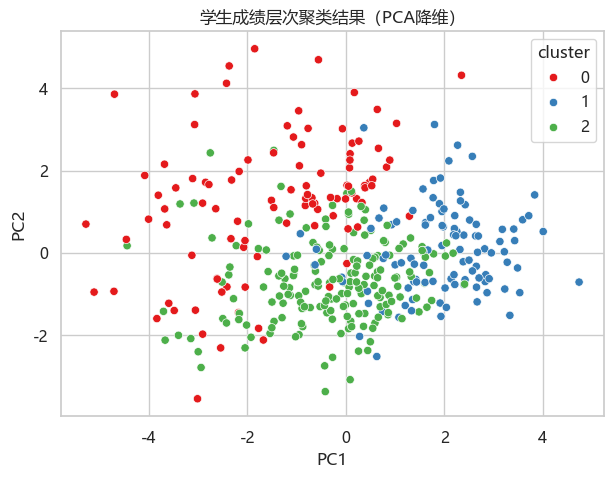

In [48]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['cluster'] = cluster_labels

plt.figure(figsize=(7, 5))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='cluster', palette='Set1')
plt.title('学生成绩层次聚类结果（PCA降维）')
plt.show()

#### 图表解读与知识点

**图表解读（PCA二维可视化）：**
- 每个点代表一个学生样本，颜色表示其聚类类别。
- 若同一颜色点**更集中**、不同颜色**分离明显**，说明聚类效果较好。
- 若颜色高度混杂，说明该簇划分可能不清晰。

**知识点讲解：**
- **PCA**将高维特征压缩到2D，便于可视化，不改变聚类结果。
- 这是“可视化辅助”，不等价于最终结论。
- 可尝试更换K值或特征集合，观察可视化变化。

### 13. 小结与思考题

1. 如果将 `linkage` 换成 `complete` 或 `average`，树状图形态会有何变化？
2. K 值选得过大或过小，对聚类结果的解释会产生什么影响？
3. 若只使用成绩相关特征（如G1、G2、G3），聚类结果是否更易解释？